In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [18]:
df = pd.read_csv("data/all_data_merged.csv", parse_dates=["DATE"])
df = df.sort_values(["DISTRICT", "DATE"]).reset_index(drop=True)

ohe = OneHotEncoder(sparse_output=False)
district_onehot = ohe.fit_transform(df[["DISTRICT"]])

X_base = df[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM",
             "POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
X_raw = np.hstack([X_base, district_onehot])
y_raw = df["CONGESTION"].values.reshape(-1, 1)

sx, sy = MinMaxScaler(), MinMaxScaler()
Xs = sx.fit_transform(X_raw)
ys = sy.fit_transform(y_raw)

seq_len = 10
Xs_seq, ys_seq, districts_seq = [], [], []
for i in range(len(Xs) - seq_len):
    Xs_seq.append(Xs[i:i+seq_len])
    ys_seq.append(ys[i+seq_len])
    districts_seq.append(df["DISTRICT"].iloc[i+seq_len])
Xs_seq, ys_seq, districts_seq = np.array(Xs_seq), np.array(ys_seq), np.array(districts_seq)

In [19]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim=32, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:, -1, :])

n_features = Xs_seq.shape[-1]
model = LSTMRegressor(n_features=n_features, hidden_dim=32, n_layers=1)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

batch_size = 128
X_train = torch.tensor(Xs_seq, dtype=torch.float32)
y_train = torch.tensor(ys_seq, dtype=torch.float32)

train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
n_epochs = 20

model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    avg_loss = total_loss / len(X_train)
    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_loss:.5f}")

Epoch 1/20 - Train Loss: 0.01627
Epoch 2/20 - Train Loss: 0.00475
Epoch 3/20 - Train Loss: 0.00462
Epoch 4/20 - Train Loss: 0.00451
Epoch 5/20 - Train Loss: 0.00447
Epoch 6/20 - Train Loss: 0.00439
Epoch 7/20 - Train Loss: 0.00418
Epoch 8/20 - Train Loss: 0.00311
Epoch 9/20 - Train Loss: 0.00292
Epoch 10/20 - Train Loss: 0.00271
Epoch 11/20 - Train Loss: 0.00258
Epoch 12/20 - Train Loss: 0.00249
Epoch 13/20 - Train Loss: 0.00243
Epoch 14/20 - Train Loss: 0.00223
Epoch 15/20 - Train Loss: 0.00216
Epoch 16/20 - Train Loss: 0.00206
Epoch 17/20 - Train Loss: 0.00204
Epoch 18/20 - Train Loss: 0.00176
Epoch 19/20 - Train Loss: 0.00177
Epoch 20/20 - Train Loss: 0.00151


District 1: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.03


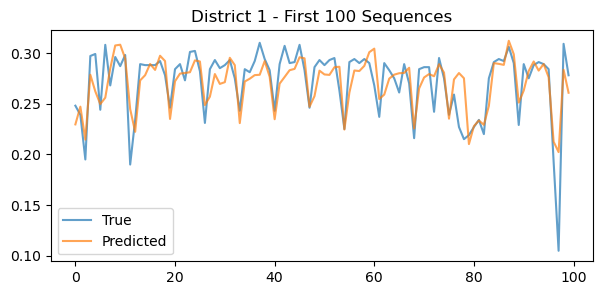

District 2: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


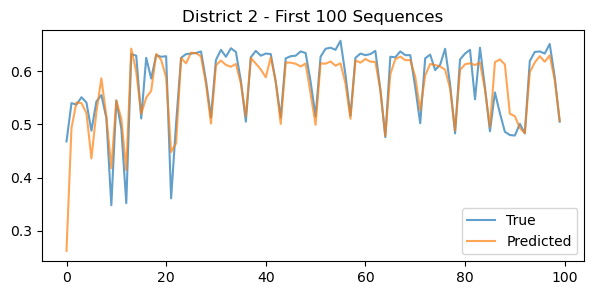

District 3: MSE=0.00, MAE=0.03, Predicted std: 0.05, True std: 0.07


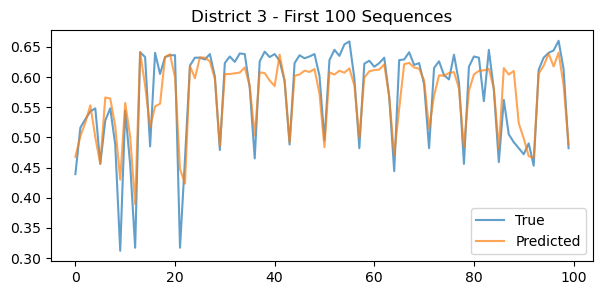

District 4: MSE=0.00, MAE=0.02, Predicted std: 0.06, True std: 0.07


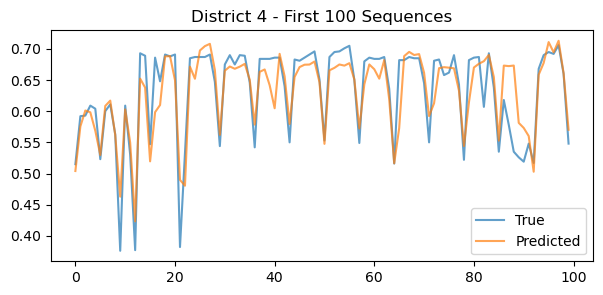

District 5: MSE=0.00, MAE=0.02, Predicted std: 0.06, True std: 0.07


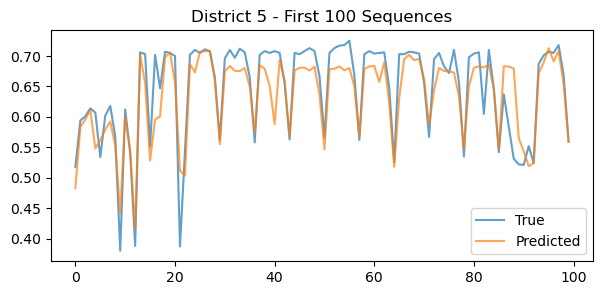

District 6: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


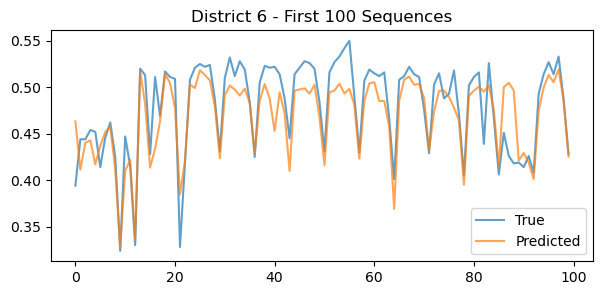

District 7: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


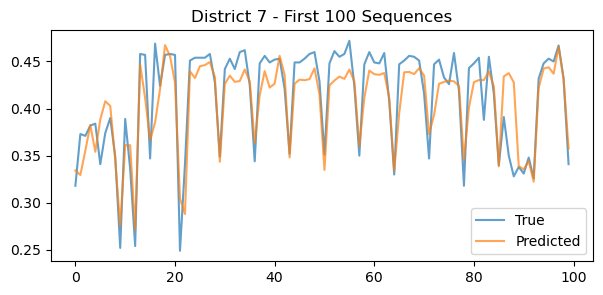

District 8: MSE=0.00, MAE=0.03, Predicted std: 0.07, True std: 0.08


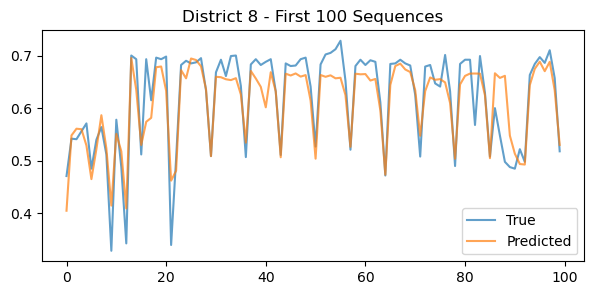

District 9: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


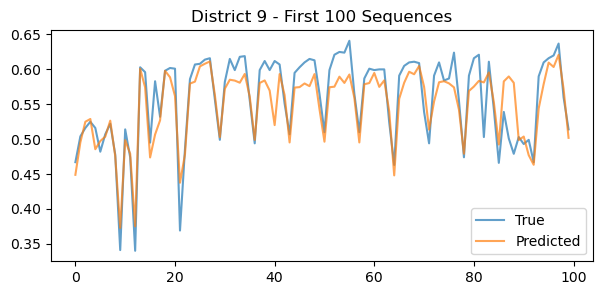

District 10: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.03


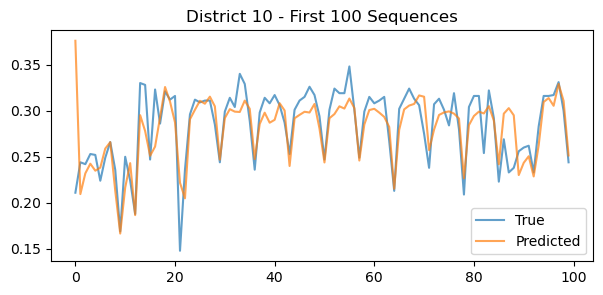

District 11: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


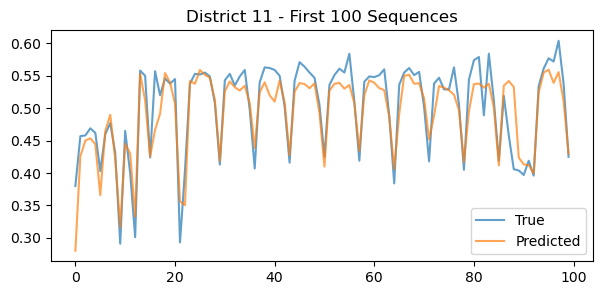

District 12: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


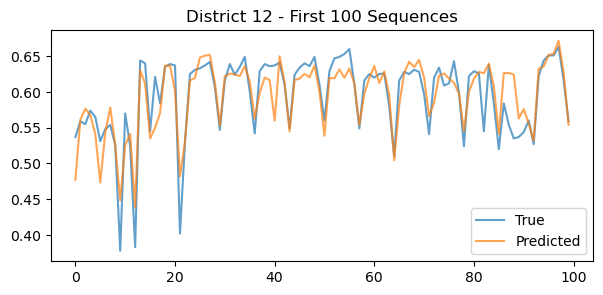

District 13: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.02


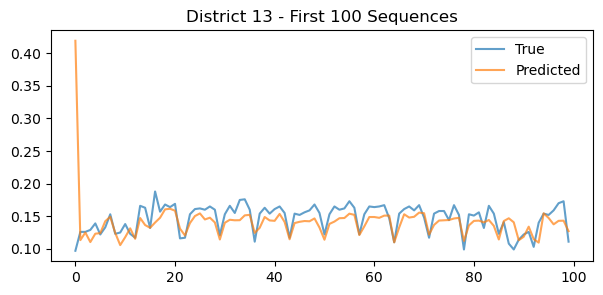

District 15: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


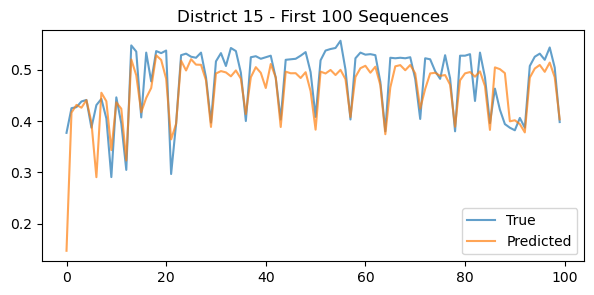

District 16: MSE=0.00, MAE=0.02, Predicted std: 0.07, True std: 0.08


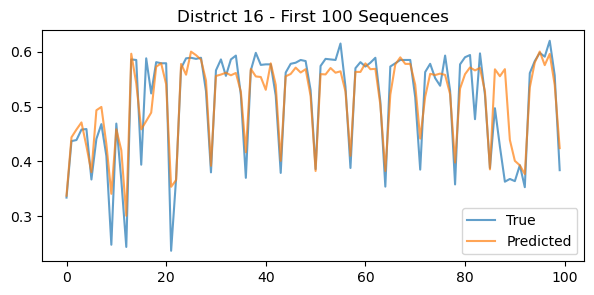

District 17: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


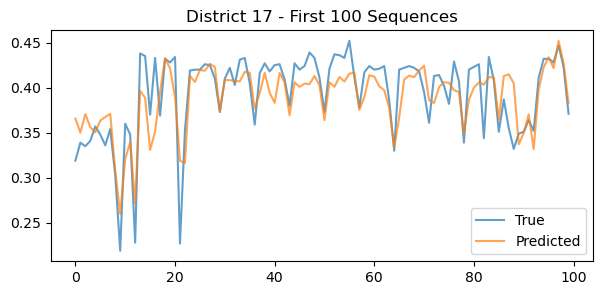

District 18: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


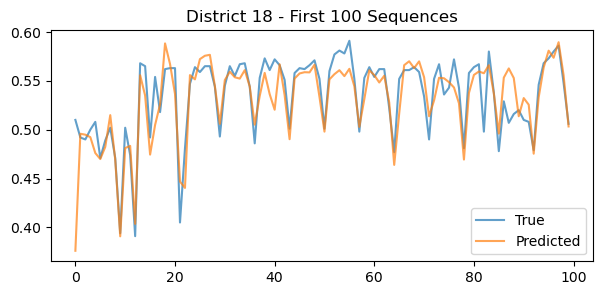

District 19: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


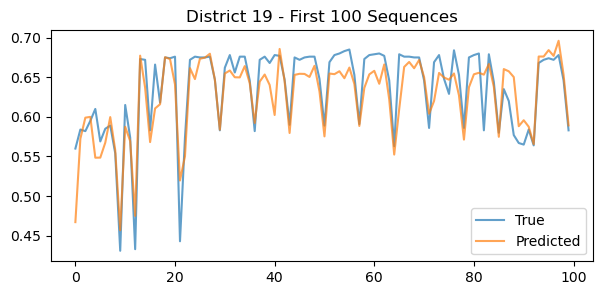

District 20: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


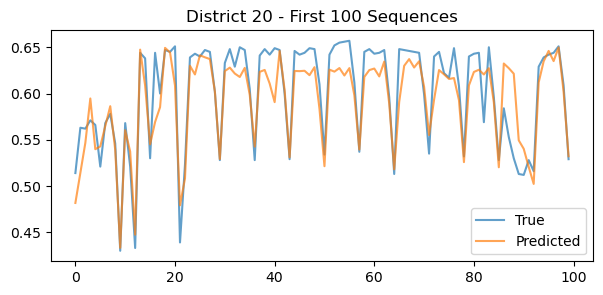

District 21: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


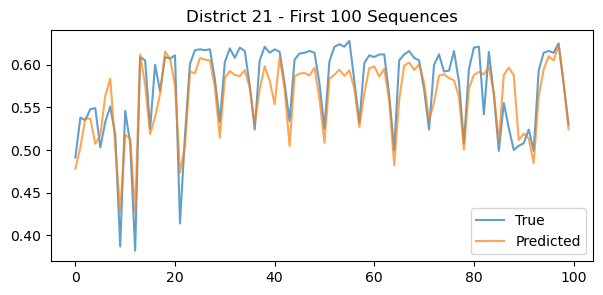

District 22: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.07


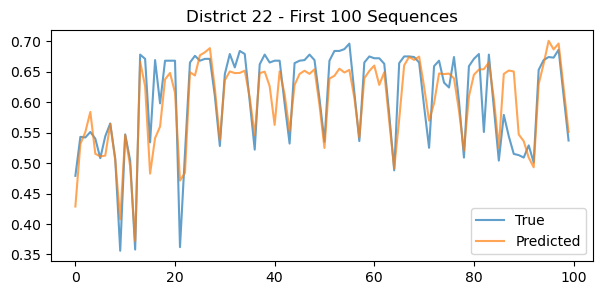

District 23: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


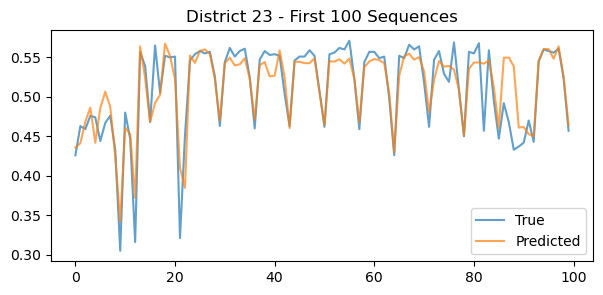

District 24: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


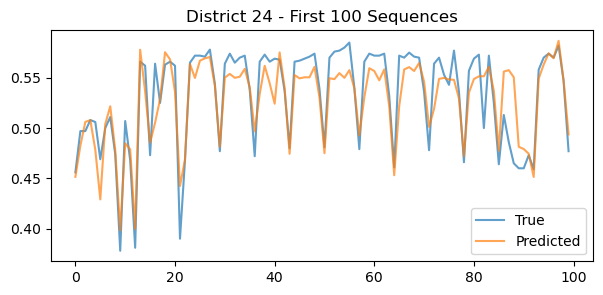

District 25: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


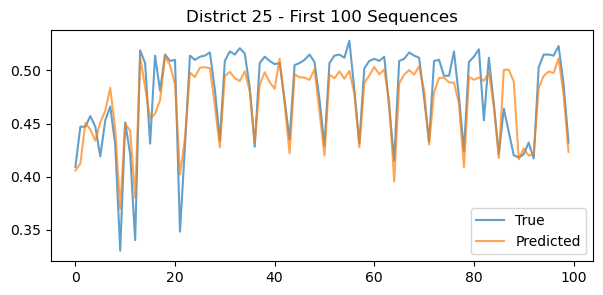

District 26: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


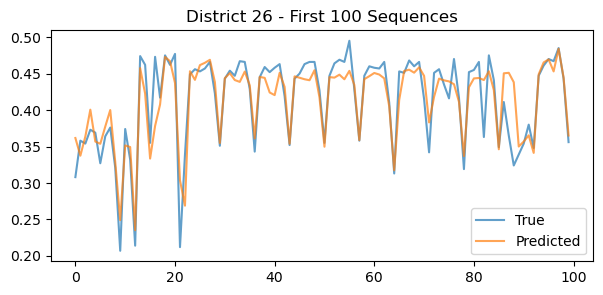

District 27: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


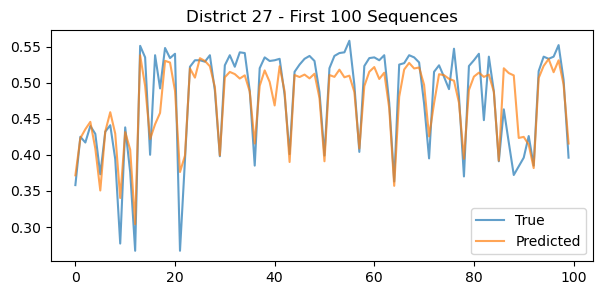

District 28: MSE=0.00, MAE=0.02, Predicted std: 0.02, True std: 0.03


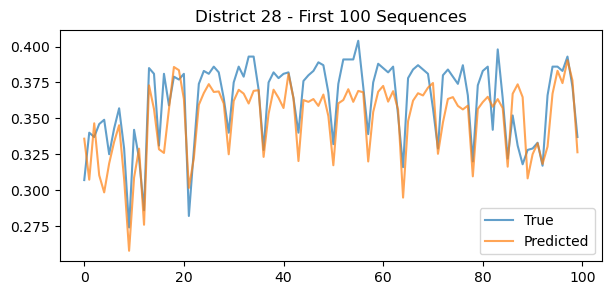

District 29: MSE=0.00, MAE=0.01, Predicted std: 0.01, True std: 0.02


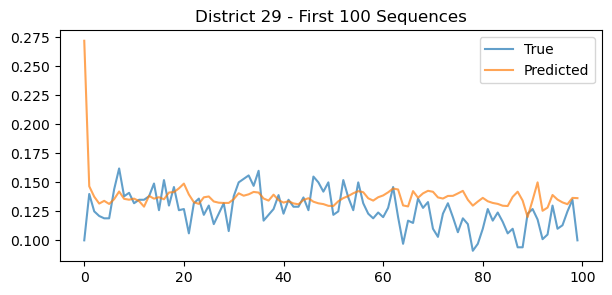

District 30: MSE=0.00, MAE=0.02, Predicted std: 0.06, True std: 0.06


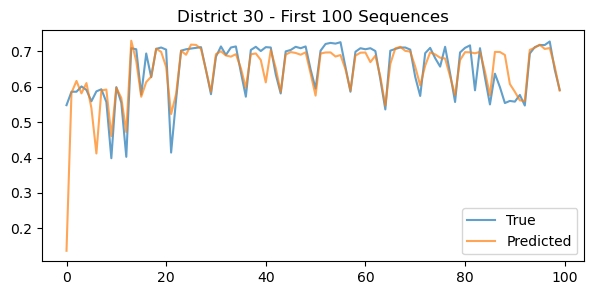

District 31: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


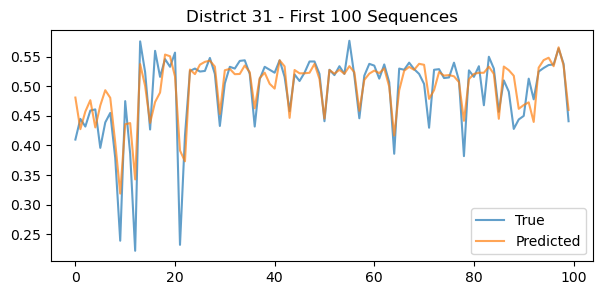

District 32: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


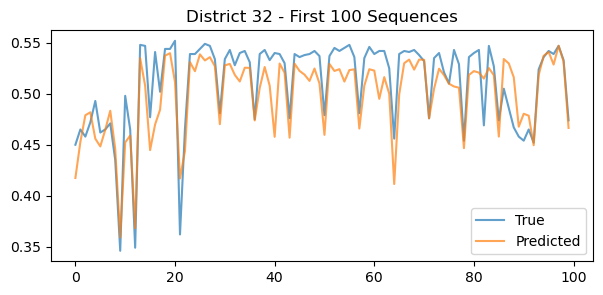

District 33: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


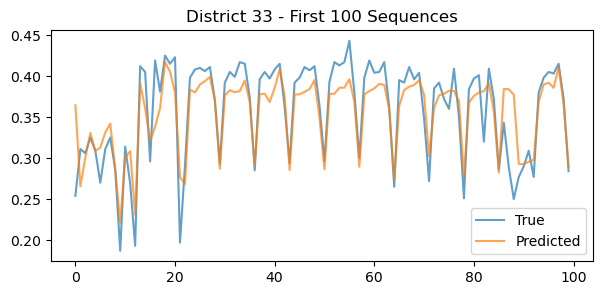

District 34: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


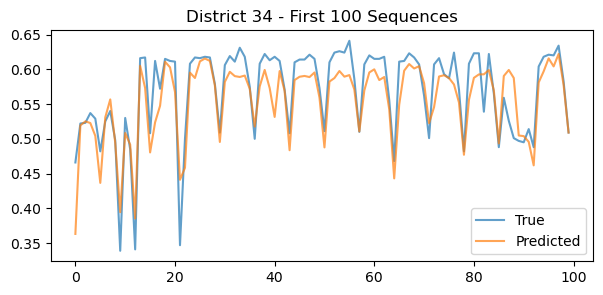

District 35: MSE=0.00, MAE=0.01, Predicted std: 0.03, True std: 0.04


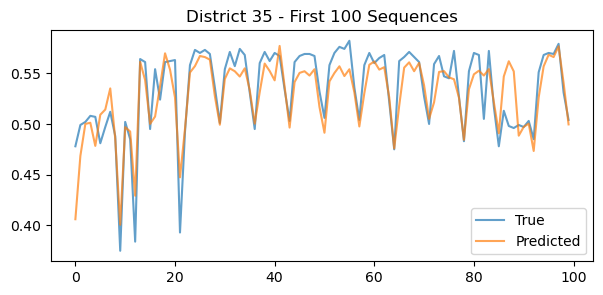

District 36: MSE=0.00, MAE=0.03, Predicted std: 0.05, True std: 0.06


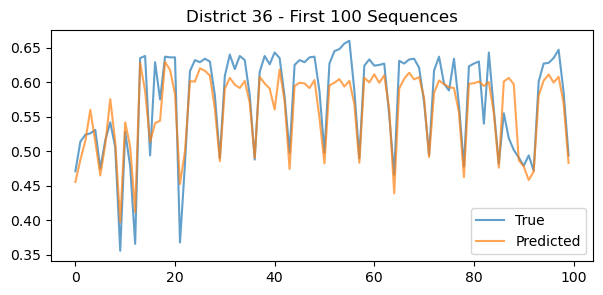

District 37: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.02


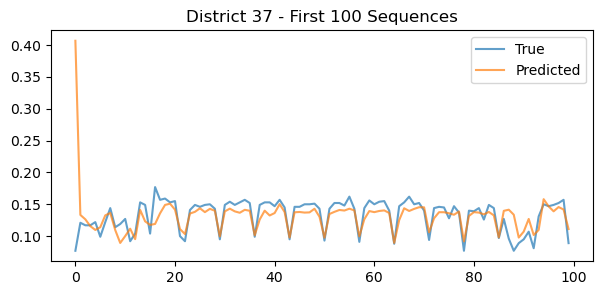

District 38: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


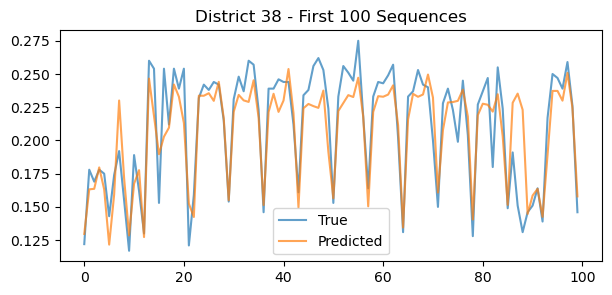

In [22]:
model.eval()
districts = np.unique(districts_seq)

for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(Xb).cpu().squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))

    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()
    std_true = y_true_inv.std()

    print(f"District {district}: MSE={mse:.2f}, MAE={mae:.2f}, Predicted std: {std_pred:.2f}, True std: {std_true:.2f}")

    plt.figure(figsize=(7,3))
    plt.plot(y_true_inv[:100], label="True", alpha=0.7)
    plt.plot(preds_inv[:100], label="Predicted", alpha=0.7)
    plt.title(f"District {district} - First 100 Sequences")
    plt.legend()
    plt.show()

In [24]:
results = []
for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))

    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()
    std_true = y_true_inv.std()

    results.append({"District": district, "MSE": mse, "MAE": mae, 
                    "Predicted Std": std_pred, "Real Std": std_true})

df_results = pd.DataFrame(results)
print(df_results.sort_values("MSE"))

    District       MSE       MAE  Predicted Std  Real Std
0          1  0.000323  0.013223       0.022237  0.027078
33        35  0.000377  0.014859       0.032010  0.035895
23        25  0.000384  0.015670       0.032206  0.037417
27        29  0.000414  0.013789       0.009427  0.015679
22        24  0.000431  0.015585       0.037855  0.043837
36        38  0.000443  0.016074       0.033141  0.040346
26        28  0.000451  0.017914       0.024848  0.026401
16        18  0.000464  0.015865       0.035415  0.035542
30        32  0.000489  0.016776       0.034231  0.039388
9         10  0.000521  0.016814       0.029846  0.034751
18        20  0.000523  0.017382       0.045020  0.049718
19        21  0.000546  0.018213       0.039081  0.043328
12        13  0.000557  0.013817       0.020558  0.018676
17        19  0.000578  0.017378       0.042393  0.047931
35        37  0.000581  0.014172       0.022324  0.022708
21        23  0.000587  0.016903       0.040587  0.048686
6          7  

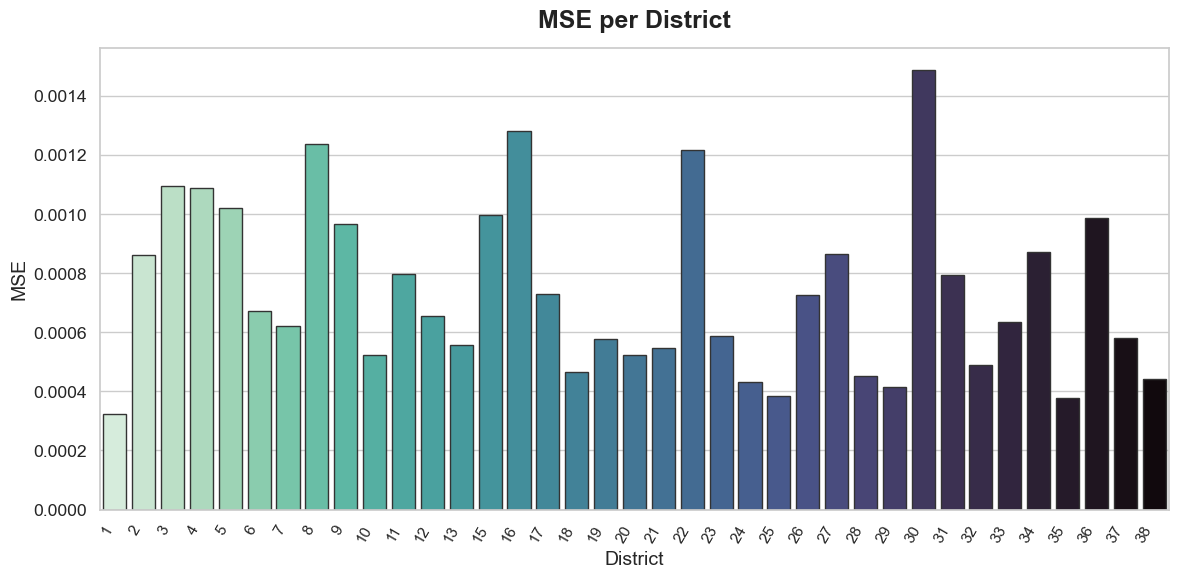

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

plt.figure(figsize=(12, 6))
sorted_df = df_results.sort_values("MSE")
bar = sns.barplot(x="District", y="MSE", data=sorted_df, palette="mako_r", edgecolor=".2")
plt.title("MSE per District", weight="bold", fontsize=18, color="#222222", pad=15)
plt.ylabel("MSE", fontsize=14)
plt.xlabel("District", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.tight_layout()
plt.show()


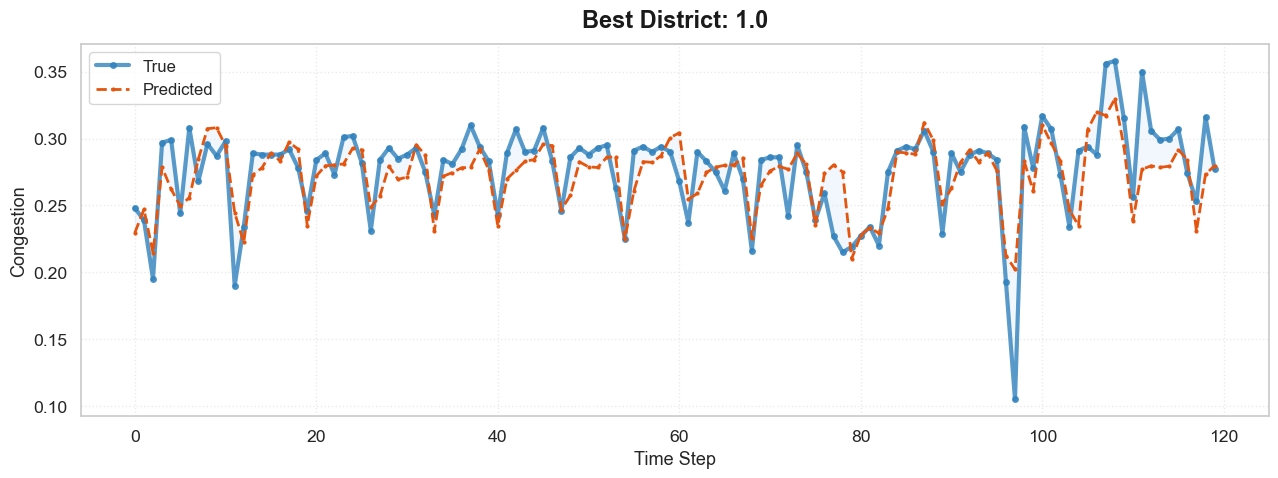

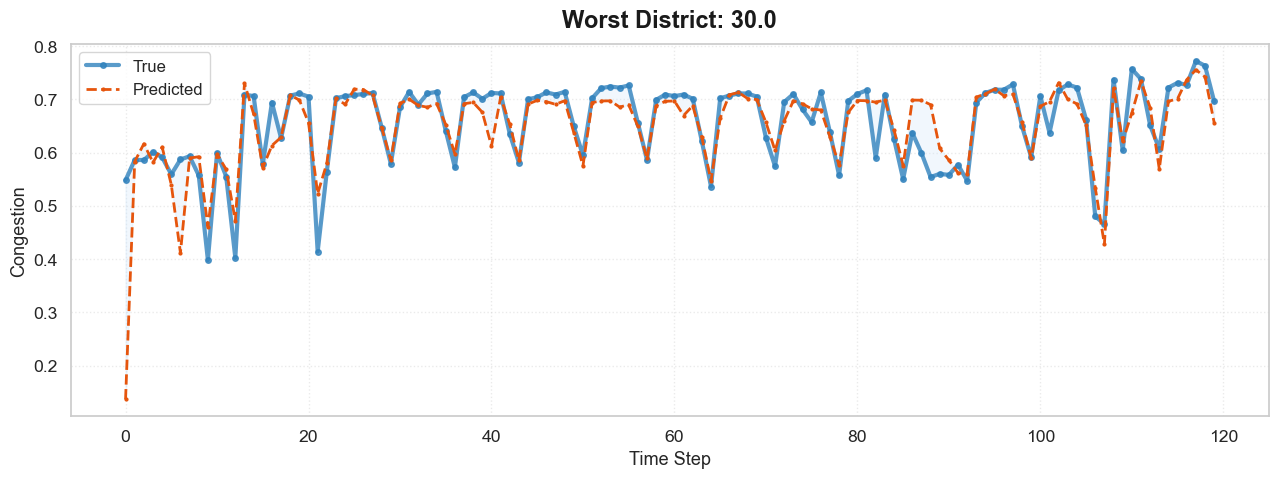

In [32]:
best = sorted_df.iloc[0]["District"]
worst = sorted_df.iloc[-1]["District"]

for name, district in zip(["Best District", "Worst District"], [best, worst]):
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]
    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))
    plt.figure(figsize=(13, 5))
    plt.plot(y_true_inv[:120], label="True", linewidth=3, color="#3182bd", alpha=0.8, marker="o", markersize=4)
    plt.plot(preds_inv[:120], label="Predicted", linewidth=2, color="#e6550d", linestyle="--", marker=".", markersize=4)
    plt.fill_between(range(120), y_true_inv[:120].flatten(), preds_inv[:120].flatten(), color="#d1e6fa", alpha=0.3)
    plt.title(f"{name}: {district}", fontsize=17, weight="bold", color="#1a1a1a", pad=12)
    plt.xlabel("Time Step", fontsize=13)
    plt.ylabel("Congestion", fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
